# MLP Basics: Brain Tumor Image Classification

In [5]:
import os
import zipfile
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Використовуваний пристрій:', device)

Використовуваний пристрій: cpu


1.- Завантажте файл з датасетом для виявлення онкологічних захворювань мозку. Архів містить два окремих набору для тренування та тестування. Для валідації використовуйте зображення з тренувального датасету.

In [6]:
with zipfile.ZipFile('brain_tumor_classification_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
print('Архів розпаковано!')

Архів розпаковано!


2.- Реалізуйте власний клас для завантаження датасету в PyTorch (зробити наслідування від torch.utils.data.Dataset).

In [3]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if not d.startswith(".") and os.path.isdir(os.path.join(root_dir, d))])
        self.class_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}
        self.samples = []

        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_path):
                continue
            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                if os.path.isfile(img_path):
                    sample = (img_path, self.class_idx[class_name])
                    self.samples.append(sample)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label_tensor = torch.tensor(label, dtype=torch.long)
        return image, label_tensor

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = BrainTumorDataset(root_dir="brain_tumor_classification_dataset/Training", transform=transform)
test_dataset = BrainTumorDataset(root_dir="brain_tumor_classification_dataset/Testing", transform=transform)

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

3.- Проведіть аналіз датасету (Exploratory Data Analysis).

In [9]:
train_df = pd.DataFrame(train_dataset.samples, columns=["img_path", "class"])
test_df = pd.DataFrame(test_dataset.samples, columns=["img_path", "class"])
train_df

,img_path,class
0,brain_tumor_classification_dataset/Training/gl...,0
1,brain_tumor_classification_dataset/Training/gl...,0
2,brain_tumor_classification_dataset/Training/gl...,0
3,brain_tumor_classification_dataset/Training/gl...,0
4,brain_tumor_classification_dataset/Training/gl...,0
...,...,...
5707,brain_tumor_classification_dataset/Training/pi...,3
5708,brain_tumor_classification_dataset/Training/pi...,3
5709,brain_tumor_classification_dataset/Training/pi...,3
5710,brain_tumor_classification_dataset/Training/pi...,3


In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5712 entries, 0 to 5711
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   img_path  5712 non-null   object
 1   class     5712 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.4+ KB


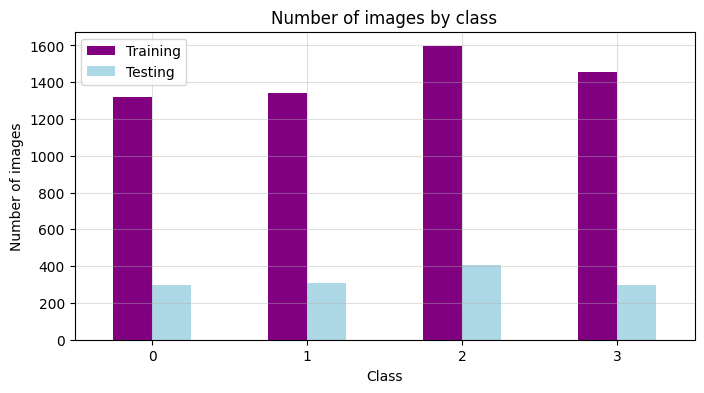

In [36]:
train_counts = train_df["class"].value_counts().sort_index()
test_counts = test_df["class"].value_counts().sort_index()
df_plot = pd.DataFrame({"Training": train_counts, "Testing": test_counts})

df_plot.plot(
    kind="bar",
    figsize=(8, 4),
    color=["purple", "lightblue"],
    title="Number of images by class",
)

plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.grid(alpha=0.4)
plt.legend()
plt.show()

**To perform EDA on image data, you need to understand the basic properties of images, such as size, shape, color, and resolution.** Then, you can use techniques **such as histograms, scatter plots, or heat maps to explore the distribution, correlation, or intensity of pixels in your image data.** You can also use **feature extraction** methods, **such as edge detection, corner detection, or convolutional neural networks (CNNs)**, to identify the key features or patterns in your image data.

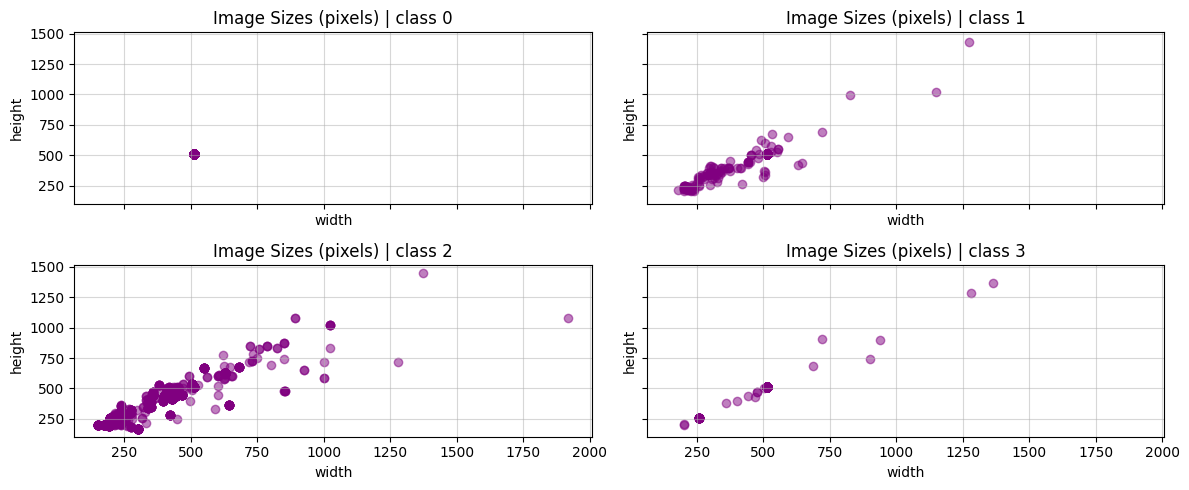

In [37]:
widths = []
heights = []

for img_path in train_df["img_path"]:
  with Image.open(img_path) as img:
    widths.append(img.size[0])
    heights.append(img.size[1])

train_df["width"] = widths
train_df["height"] = heights

classes = train_df["class"].unique()
n_classes = len(classes)

fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True, sharey=True)
axes = axes.flatten()

for idx, class_name in enumerate(classes):
  ax = axes[idx]
  subset = train_df[train_df["class"] == class_name]

  ax.scatter(
      subset["width"],
      subset["height"],
      alpha=0.5,
      color="purple"
  )
  ax.set_title(f"Image Sizes (pixels) | class {class_name}")
  ax.set_xlabel("width")
  ax.set_ylabel("height")
  ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()